<a href="https://colab.research.google.com/github/Juan-Vega18/INTRODUC.-CIENCIA-DE-DATOS/blob/main/Copy_of_clase_5_analisis_de_clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ANALISIS DE CLIENTES


|variable|Tipo de Variable|Descripción|
|---|---|---|
|CustomerID|int64 (numérica entera)|El ID (identificador) del cliente|
|Age|int64 (numérica entera)|Edad del Cliente|
|Education|object (categórica) |Nivel educativo|
|Income|int64 (numérica entera)|Ingreso económico|
|Occupation|object (categórica)|Ocupación de la persona|
|Gender|object (categórica)|Género de la persona|
|Marital Status|object (categórica)|Estado Marital de la persona|
|Settlement Size|object (categórica)|En que tipo de ciudad (tamaño) vive|


In [ ]:
#Cargamos las librerias
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import plotly.express as px


#Montamos a drive
drive.mount('/mnt/drive')
os.getcwd()
#os.listdir() Listamos los directorios
os.chdir('/mnt/drive/MyDrive/ciencia_de_datos')
os.listdir()

Drive already mounted at /mnt/drive; to attempt to forcibly remount, call drive.mount("/mnt/drive", force_remount=True).


['netflix_data.csv',
 'democracy_data.csv',
 'democracy_data.gsheet',
 'output_file.csv',
 'regicor.csv',
 'customers_1.csv',
 'introduc_ciencia_de_datos']

In [ ]:
df_hr = pd.read_csv('customers_1.csv') #Creamos el dataframe con el csv
df_hr.info() #Obtenemos información de las variables

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       2000 non-null   int64 
 1   Age              2000 non-null   int64 
 2   Education        2000 non-null   object
 3   Income           2000 non-null   int64 
 4   Occupation       2000 non-null   object
 5   Gender           2000 non-null   object
 6   Marital Status   2000 non-null   object
 7   Settlement Size  2000 non-null   object
dtypes: int64(3), object(5)
memory usage: 125.1+ KB


In [ ]:
#Hallar la media

media_edad = df_hr['Age'].mean() #Calculamos la media de la edad
media_salario = df_hr['Income'].mean() #Calculamos la media del salario
print(f'La edad promedio de la empresa es: {media_edad:.1f} años') #El f significa float y el 1 es, 1 solo decimal
print(f'El Salario promedio (Media es ${media_salario:,.2f} USD ') #Aqui pasa lo mismo pero queremos 2 decimales despues de la coma.

La edad promedio de la empresa es: 35.9 años
El Salario promedio (Media es $120,954.42 USD 


La mediana de Salario de la empresa es: $115548.500000 dolares


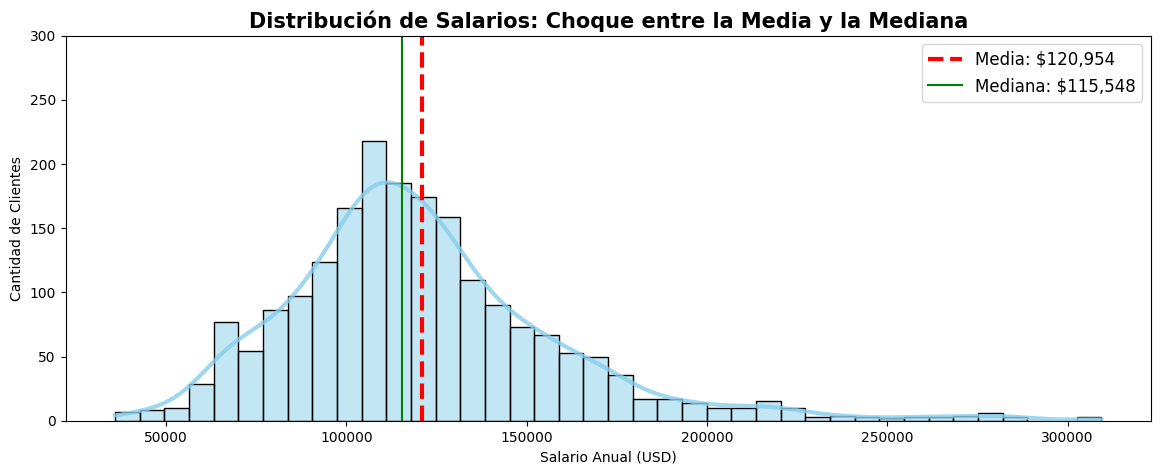

In [ ]:
#Hallar la mediana
mediana_salario = df_hr['Income'].median() #Calculamos la mediana del salario
print(f'La mediana de Salario de la empresa es: ${mediana_salario:1f} dolares')

plt.figure(figsize=(14,5)) #Tamaño de la figura
sns.histplot(df_hr['Income'], bins=40, color='skyblue', kde=True,
             line_kws={'linewidth': 3, 'color': 'navy', 'alpha': 0.8}) #Destacamos la envolvemnte en azul oscuro #Creamos el histograma de salarios

plt.axvline(media_salario, color='red', linestyle = 'dashed', linewidth = 3, label=f'Media: ${media_salario:,.0f}') #Añadimos las lineas verticales de media y mediana
plt.axvline(mediana_salario, color='green', linestyle = 'solid', label=f'Mediana: ${mediana_salario:,.0f}')

plt.title('Distribución de Salarios: Choque entre la Media y la Mediana', fontsize= 15, fontweight ='bold') #Asignamos titulo del plot
plt.xlabel('Salario Anual (USD)') #Titulo eje x
plt.ylabel('Cantidad de Clientes') #Titulo eje y
plt.ylim(0,300) #Definimos los limites
plt.legend(fontsize=12) #Definimos la fuente de la legenda
plt.show()

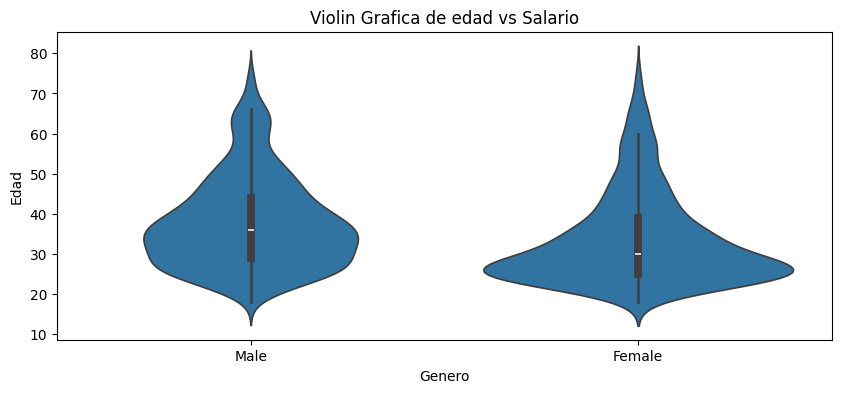

In [ ]:
# Violin plot
plt.figure(figsize=(10, 4)) #Tamaño de la figura
sns.violinplot(y='Age', x='Gender', data=df_hr) #Creo el grafico violin y defino las variables y e x.
plt.title('Violin Grafica de edad vs Salario') #Defino el titulo del plot
plt.xlabel('Genero') #Defino el titulo del eje x
plt.ylabel('Edad') #Defino del titulo del eje y
plt.show()

115548.5


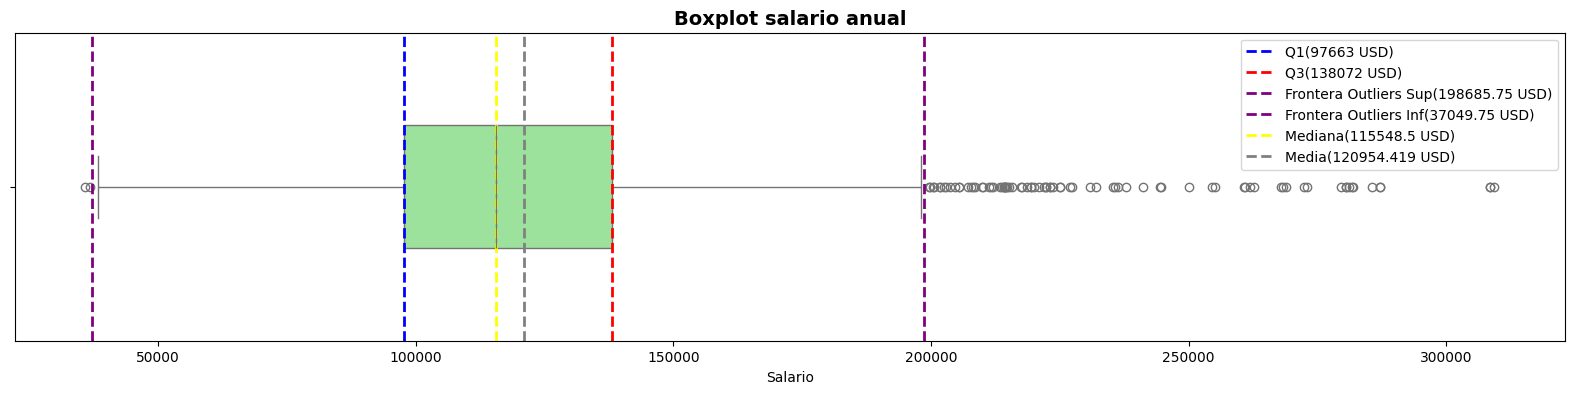

In [ ]:
plt.figure(figsize=(20,4)) #Defino tamaño de la figura boxplot
sns.boxplot(x=df_hr['Income'], color='lightgreen', width=0.4) #creo el boxplot y pongo como variable income
Q1 = df_hr['Income'].quantile(0.25) #Calculo el Cuartil 1
mediana = df_hr['Income'].median() #Calculo la mediana
media = df_hr['Income'].mean() #Calculo la media
Q3 = df_hr['Income'].quantile(0.75) #Calculo el Cuartil 3
IQR = Q3 - Q1 #Calculo el rango intercuartilico
lim_sup = Q3 + 1.5*IQR #Calculo el limite superior
lim_inf = Q1 - 1.5*IQR #Calculo del limite inferior
print(mediana)

#trazos verticales
#Creo todos los trazos verticales para los cuartiles, fronteras, mediana y media.
plt.axvline(Q1, color = 'blue', linestyle ='--', linewidth ='2', label=f'Q1({Q1:.0f} USD)')
plt.axvline(Q3, color = 'red', linestyle ='--', linewidth ='2', label=f'Q3({Q3:.0f} USD)')
plt.axvline(lim_sup, color = 'purple', linestyle ='--', linewidth ='2', label=f'Frontera Outliers Sup({lim_sup} USD)')
plt.axvline(lim_inf, color = 'purple', linestyle ='--', linewidth ='2', label=f'Frontera Outliers Inf({lim_inf} USD)')
plt.axvline(mediana, color = 'yellow', linestyle ='--', linewidth ='2', label=f'Mediana({mediana} USD)')
plt.axvline(media, color = 'gray', linestyle ='--', linewidth ='2', label=f'Media({media} USD)')

plt.title('Boxplot salario anual', fontsize=14, fontweight='bold') #Defino titulo del boxplot
plt.xlabel('Salario') #Defino el nombre del eje x
plt.legend()
plt.show()

Cuando comparamos dos variables continuas o numéricas (Age), (Income), buscamos entender si el cambio en una varialbe está asociado con el cambio en la otra. La métrica reina para esto es el coeficiente de correlación de pearson (r).

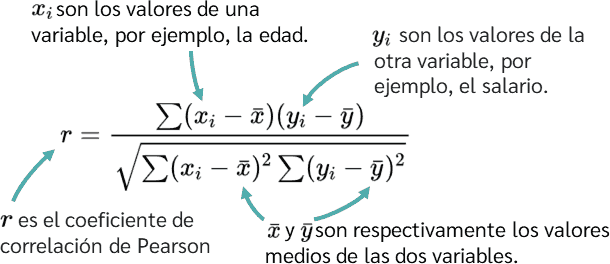

EL numerador es la covarianza de X e Y (y como varian juntos), el denominador es el producto de las desviaciones estandar de X e Y, que normaliza el valor para que siempre esté entre -1 y 1.

In [ ]:
correlacion = df_hr[['Age', 'Income']].corr(method='pearson')
print('Matriz de correlación: ')
display(correlacion)

#El coeficiente de correlación r puede ser: r>0, r<0.
#El coeficiente de pearson solo sirve para relaciones entre 2 variables intentando encontrar una relación
#lineal.
#Si queremos probar otras relaciones, como cuadrática, exponencial, logistica o cualquier forma no lineal.
#Existen:
#Corr. Spearman (rho) -> monotonica, no requiere linealidad, Corr. Kendall (tau) -> monotonica, basada en
#ordenamientos.

Matriz de correlación: 


,Age,Income
Age,1.00000,0.34061
Income,0.34061,1.00000


El coeficiente de correlación de Pearson, `r`, se calcula con la siguiente fórmula:

$$r = \frac{\sum_{i=1}^{n}((X_i - \bar{X})(Y_i - \bar{Y}))}{\sqrt{\sum_{i=1}^{n}(X_i - \bar{X})^2}\sqrt{\sum_{i=1}^{n}(Y_i - \bar{Y})^2}}$$

También se puede expresar en términos de covarianza y desviaciones estándar:

$$r = \frac{Cov(X, Y)}{\sigma_X \sigma_Y}$$

Donde:

*   $X_i$ y $Y_i$ son los valores individuales de las variables X e Y.
*   $\bar{X}$ y $\bar{Y}$ son las medias de las variables X e Y.
*   $n$ es el número de observaciones.
*   $Cov(X, Y)$ es la **covarianza** entre X e Y, que mide cómo varían conjuntamente las dos variables. El numerador de la fórmula de Pearson es precisamente la suma que se usa para calcular la covarianza (sin dividir por `n-1` o `n`).
*   $\sigma_X$ y $\sigma_Y$ son las **desviaciones estándar** de X e Y, respectivamente, que miden la dispersión o variabilidad de cada variable por separado. La raíz cuadrada de la suma de los cuadrados de las diferencias con la media, dividida por `n-1` (o `n`), es la desviación estándar.

### ¿Por qué la multiplicación de las desviaciones estándar y la raíz en el denominador?

La razón principal de esta estructura en el denominador es la **normalización**.

1.  **Eliminar la dependencia de la escala**: La covarianza ($Cov(X, Y)$) puede tener cualquier valor y su magnitud depende de las unidades de medida de X e Y. Esto hace difícil interpretar si una covarianza de, digamos, 100 indica una relación fuerte o débil. Al dividir la covarianza por el producto de las desviaciones estándar de X e Y, el coeficiente de Pearson se **normaliza** para que su valor siempre esté entre -1 y 1.

2.  **Facilitar la interpretación**: Esta normalización permite que `r` tenga una interpretación universal:
    *   `+1` indica una correlación lineal positiva perfecta.
    *   `-1` indica una correlación lineal negativa perfecta.
    *   `0` indica ausencia de correlación lineal.

    El producto de las desviaciones estándar en el denominador actúa como un factor de escala. Sin él, la covarianza por sí sola no nos diría qué tan fuerte es la relación en términos relativos. Las desviaciones estándar, al cuantificar la variabilidad individual de cada variable, proporcionan el contexto necesario para "estandarizar" la covarianza y transformarla en un coeficiente de correlación interpretable.

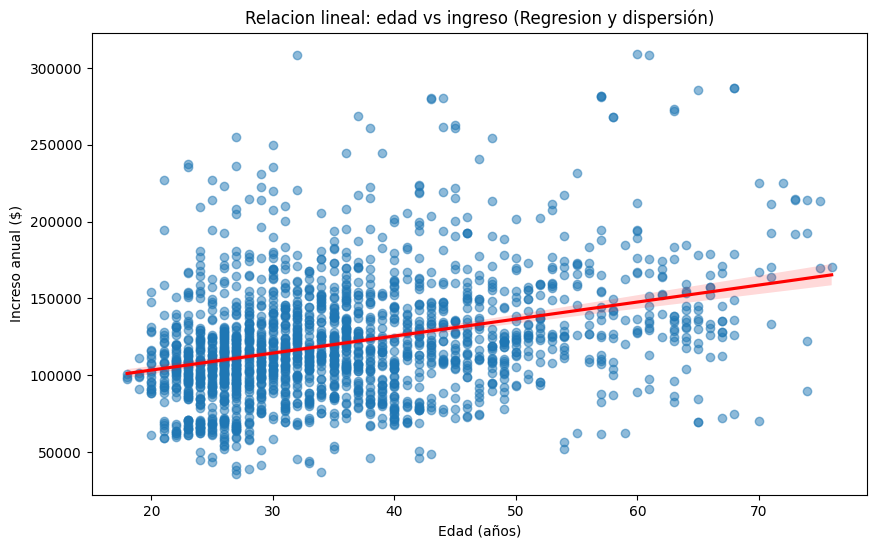

In [ ]:
#visualizacion

plt.figure(figsize=(10,6))
sns.regplot(data=df_hr, x='Age', y='Income', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relacion lineal: edad vs ingreso (Regresion y dispersión)')
plt.xlabel('Edad (años)')
plt.ylabel('Increso anual ($)')
plt.show()

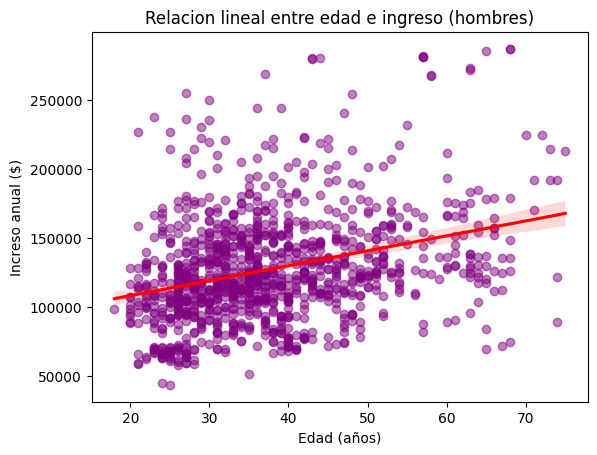

In [ ]:
#Grafica por hombres:
df_hombres = df_hr[df_hr['Gender'] == 'Male']
sns.regplot(data=df_hombres, x='Age', y='Income',
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, color='purple')
plt.title('Relacion lineal entre edad e ingreso (hombres)')
plt.xlabel('Edad (años)')
plt.ylabel('Increso anual ($)')
plt.show()


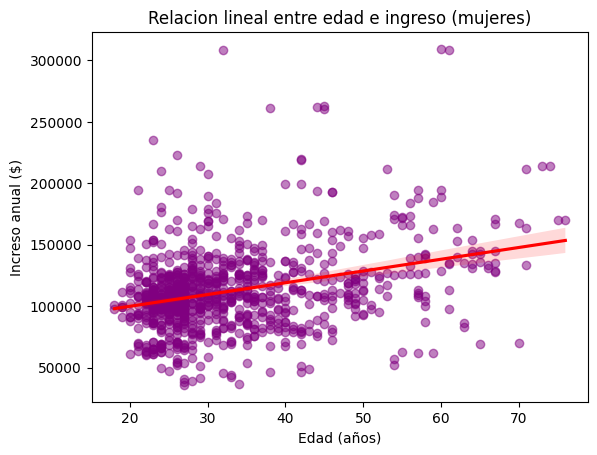

In [ ]:
#Grafica por mujeres:
df_mujeres = df_hr[df_hr['Gender'] == 'Female']
sns.regplot(data=df_mujeres, x='Age', y='Income',
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, color='purple')
plt.title('Relacion lineal entre edad e ingreso (mujeres)')
plt.xlabel('Edad (años)')
plt.ylabel('Increso anual ($)')
plt.show()


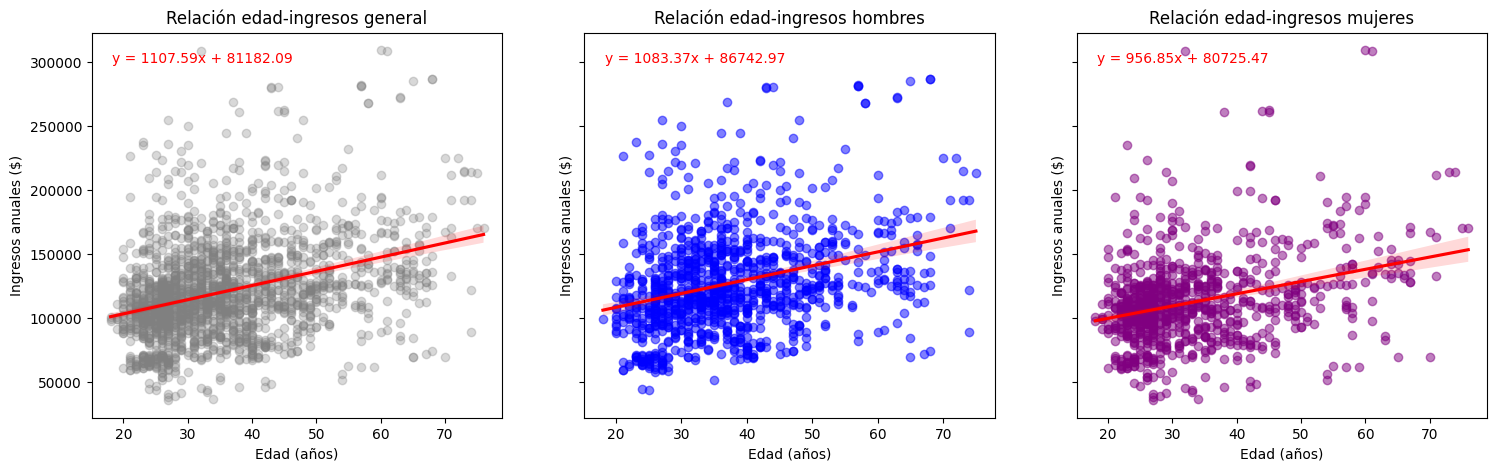

In [ ]:
#Cuando queremos graficar multiples cosas en un mismo plot, creamos una figura con m filas y n columnas
fig, axes = plt.subplots(1, 3, figsize= (18,5), sharey=True)
#1. Plot de todos juntos (Gris y Rojo)
sns.regplot(data=df_hr, x='Age', y='Income', ax=axes[0],
            scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'red'})
m1, b1 = np.polyfit(df_hr['Age'], df_hr['Income'],1)
axes[0].text(0.05,0.95, f'y = {round(m1,2)}x + {round(b1,2)}', transform=axes[0].transAxes,
             color='red', va='top')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Ingresos anuales ($)')
axes[0].set_title('Relación edad-ingresos general')



sns.regplot(data=df_hombres, x='Age', y='Income', ax=axes[1],
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, color='blue')
m2, b2 = np.polyfit(df_hombres['Age'], df_hombres['Income'],1)
axes[1].text(0.05,0.95, f'y = {round(m2,2)}x + {round(b2,2)}', transform=axes[1].transAxes,
             color='red', va='top')
axes[1].set_xlabel('Edad (años)')
axes[1].set_ylabel('Ingresos anuales ($)')
axes[1].set_title('Relación edad-ingresos hombres')


sns.regplot(data=df_mujeres, x='Age', y='Income', ax=axes[2],
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, color='purple')
m3, b3 = np.polyfit(df_mujeres['Age'], df_mujeres['Income'],1)
axes[2].text(0.05,0.95, f'y = {round(m3,2)}x + {round(b3,2)}', transform=axes[2].transAxes,
             color='red', va='top')
axes[2].set_xlabel('Edad (años)')
axes[2].set_ylabel('Ingresos anuales ($)')
axes[2].set_title('Relación edad-ingresos mujeres')

plt.show()

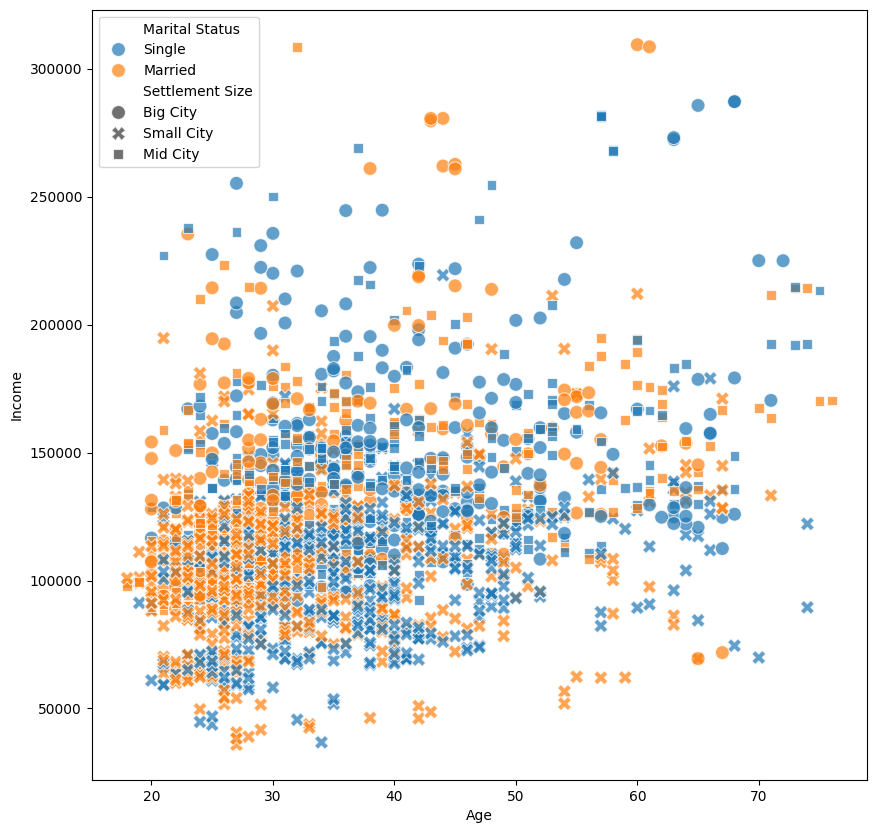

In [ ]:
#Grafico multivariado X = Age, Y = Income, Color= Marital Status, Forma = Gender.
plt.figure(figsize=(10,10))
sns.scatterplot(data=df_hr, x='Age', y='Income', hue ='Marital Status', style='Settlement Size', s=100, alpha=0.7)
plt.show()


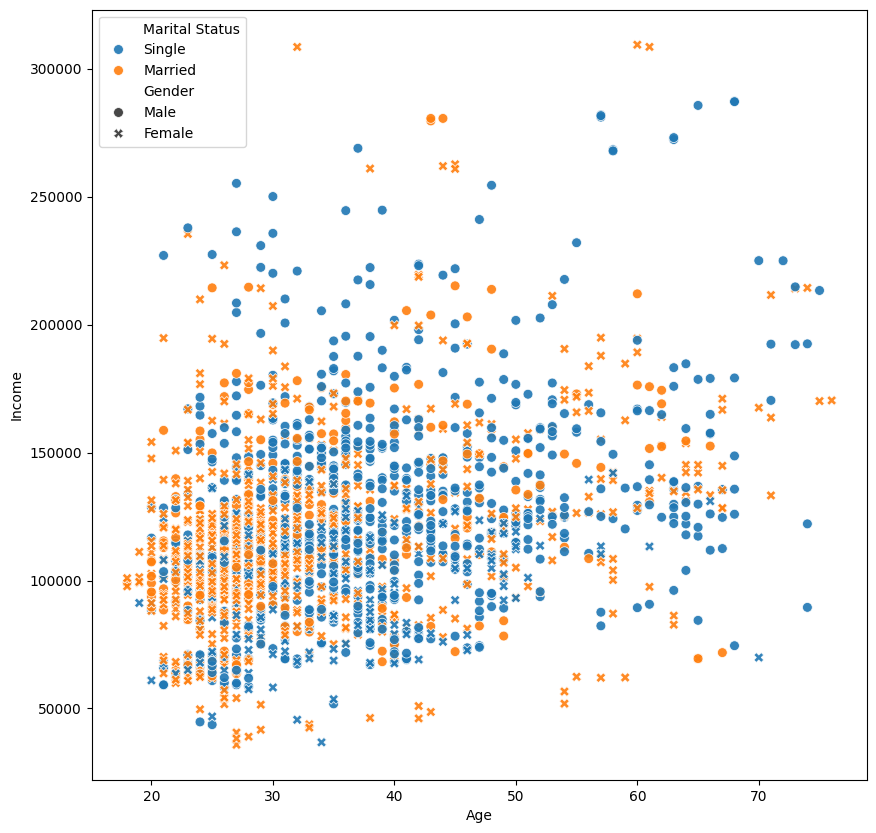

In [ ]:
#Grafico multivariado X = Age, Y = Income, Color= Marital Status, Forma = Gender.
plt.figure(figsize=(10,10))
sns.scatterplot(data=df_hr, x='Age', y='Income', hue ='Marital Status', style='Gender', s=50, alpha=0.9)
plt.show()


In [ ]:
#Grafico interactivo
fig = px.scatter(df_hr, x='Age', y='Income',
                 color='Marital Status', symbol='Gender',
                 hover_data=['Education', 'Occupation', 'Settlement Size'],
                 title='Explorador de Clientes Interactivo (Haz hover, clickea la leyenda o haz zoom)',
                 opacity=0.7)
fig.show()